# Granada 2019-20 Web Scraping and Pandas
### By Edd Webster
Notebook last updated: 01/11/2019

![title](./images/la-liga-banner-1920.jpg)

## Introduction
This notebook is a short Exploratory Data Analysis (EDA) of La-Liga xG data from the first ten games of the 2019/20 season of La Liga, Spain's top flight football division. This notebook demonstrates how to use the BeautifulSoup Python library to scrape and analyse xG data 

For more information about this notebook and the author, I'm available through all the following channels:
*    [EddWebster.com](https://www.eddwebster.com/),
*    edd.j.webster@gmail.com,
*    [@eddwebster](https://www.twitter.com/eddwebster),
*    [LinkedIn.com/in/eddwebster](https://www.linkedin.com/in/eddwebster/),
*    [GitHub/eddwebster](https://github.com/eddwebster/),
*    [Kaggle.com/eddwebster](https://www.kaggle.com/eddwebster), and
*    [HackerRank.com/eddwebster](https://www.hackerrank.com/eddwebster).

## Notebook Contents
1.    [Notebook Dependencies](#section1)<br>
2.    [Project brief](#section2)<br>
3.    [Data Scraping](#section3)<br>
      3.1  [Background Information](#section3.1)<br>
      3.2  [What is xG?](#section3.2)<br>
      3.3  [Project Hypothesis](#section3.3)<br>
4.    [Exploratory Data Analysis (EDA)](#section4)<br>
      4.1  [](#section4.1)<br>
      4.2  [](#section4.2)<br>
5.   [Summary](#section5)<br>
6.   [Bibliography](#section6)<br>
7.   [Appendix](#section7)<br>

<a id='section1'></a>

## 1. Notebook Dependencies

This notebook was written using [Python 3](https://docs.python.org/3.7/) and requires the following libraries:
*    [Jupyter notebooks](https://jupyter.org/) for this interactive computational environment that the project is presented,
*    [NumPy](http://www.numpy.org/) for multidimensional array computing,
*    [pandas](http://pandas.pydata.org/) for data manipulation and ingestion, and
*    [matplotlib](http://matplotlib.org/) and [Seaborn](https://seaborn.pydata.org/) for data visualisation, and
*    [BeautifulSoup](https://www.crummy.com/software/BeautifulSoup/bs4/doc/) and [Selenium](https://www.seleniumhq.org/) for scraping the data.

All packages used for this notebook except for BeautifulSoup can be obtained by downloading and installing the [Conda](https://anaconda.org/anaconda/conda) distribution, available on all platforms (Windows, Linux and Mac OSX). Step-by-step guides on how to install Anaconda can be found for Windows [here](https://medium.com/@GalarnykMichael/install-python-on-windows-anaconda-c63c7c3d1444) and Mac [here](https://medium.com/@GalarnykMichael/install-python-on-mac-anaconda-ccd9f2014072), as well as in the Anaconda documentation itself [here](https://docs.anaconda.com/anaconda/install/).

In [1]:
# Import modules

# Python ≥3.5 (ideally)
import sys
assert sys.version_info >= (3, 5)

# Data preprocessing
import numpy as np
import pandas as pd
import os
import re
import random
import requests

# Web scraping
from bs4 import BeautifulSoup    # pip install BeautifulSoup
from selenium import webdriver   # pip install Selenium

# Plotting figures
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

# Display in Jupyter
from IPython.core.display import HTML
from IPython.display import Image, YouTubeVideo

# Ignore warnings
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

print("Setup Complete")

Setup Complete


<a id='section2'></a>

## 2. Project Brief

### Background Information
On [27th October 2019](https://www.bbc.co.uk/sport/football/50201822), the league leaders of [La Liga](https://en.wikipedia.org/wiki/2019%E2%80%9320_La_Liga) after the first ten games of the season was not the usual suspects - Barcelona, Real Madrid or even Athletico Madrid, but it was in fact newly promoted [Granada](https://en.wikipedia.org/wiki/2019%E2%80%9320_Granada_CF_season), who were enjoying their new-found status om Spain's, top flight at the top of the pile. The Andalusian club's 1-0 victory over Real Betis took advantage of [El Clasico being postponed](https://www.bbc.co.uk/sport/football/50096390), moving up from sixth to top with 20 points from 10 games.

![title](./images/la-liga-table-bbc-27112019.png)

Granada were promoted from [The Campeonato Nacional de Liga de Segunda División](https://en.wikipedia.org/wiki/Segunda_Divisi%C3%B3n), known as LaLiga 2, in the previous season, [finishing as runners up to Osasuna with 79 points from 42 games](https://en.wikipedia.org/wiki/2018%E2%80%9319_Segunda_Divisi%C3%B3n).

According to Transfermarkt, [Granada's squad is worth £30.15m](https://www.transfermarkt.co.uk/fc-granada/startseite/verein/16795/saison_id/2019) (as of 11th November 2019), making their squad the least valueable squad in the league. Comparing this to [Real Madrid](https://www.transfermarkt.co.uk/real-madrid/startseite/verein/418/saison_id/2019) and [Barcelona](https://www.transfermarkt.co.uk/fc-barcelona/startseite/verein/131/saison_id/2019), who's squads are valued at £1.07bn and £1.06bn respectively. The value of all 20 LaLiga clubs can be found [here](https://www.transfermarkt.co.uk/laliga/startseite/wettbewerb/ES1).

Granada have never won a major trophy in their 86-year history, going closest when they lost the 1958-59 Spanish Cup final to Barcelona. Their highest La Liga finish is sixth, on two occasions in the 1970s. This projects aims to look at whether this run is sustainable and Granada can shock pundits, much like [Leicester did in 2015/16 season](https://www.bbc.co.uk/sport/football/35988673).

### What is xG?
["Expected goals"](https://en.wikipedia.org/wiki/Expected_goals) or more commonly known as 'xG', is a revolutionary, new football metric, which allows you to evaluate team and player performance. In a low-scoring game such as football, final match score does not provide a clear picture of performance. More and more professional clubs and sports analytics teams are now turning to the advanced models like xG, which is a statistical measure of the quality of chances created and conceded.

As a metric, xG assesses every chance, essentially answering the question of whether a player should have scored from a certain opportunity. Put simply, it is a way of assigning a "quality" value (xG) to every attempt based on what we know about it. The higher the xG - with 1 being the maximum - the more likelihood of the opportunity being taken. So if a chance is 0.5xG, it should be scored 50% of the time.

xG was created by football data experts [Opta](https://www.optasports.com/) after analysing over 300,000 shots to calculate the likelihood of an attempt being scored from a specific position on the pitch during a particular phase of play.

The factors taken into account when assessing the quality of a chance include:
*    Distance from goal
*    Angle of the shot
*    Did the chance fall at the player's feet or was it a header?
*    Was it a one on one?
*    What was the assist like? (eg long ball, cross, through ball, pull-back)
*    In what passage of play did it happen? (eg open play, direct free-kick, corner kick)
*    Has the player just beaten an opponent?
*    Is it a rebound?

The expected goals value reveals a number of things including:
*    Whether a chance really is as good as we think. While football is still a game that where debate and opinion make a huge part of the build up and analysis of matches, using xG we can now say with some certainty whether an opportunity should have been taken.
*    How many goals an individual player should be scoring from the chances their have. A striker might be top of the scoring charts, but does that necessarily mean he is the best finisher in the league? Previously we might have simply looked at their conversion rate (how many of their chances ended up as goals), but this did not provide the whole picture, as someone with a high conversion rate might just be the beneficiary of their team creating really clear-cut chances.
*    Team performance. If a team is performing above or below expectations at the start of the new season, a look at their expected goals difference could tell you whether that run is likely to last.

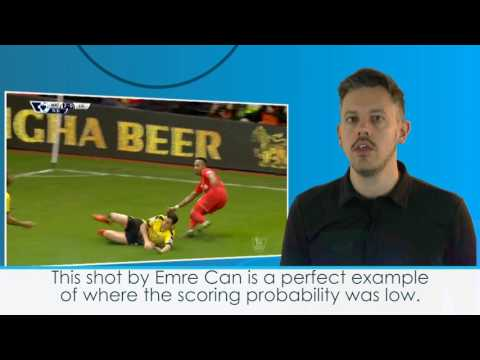

In [2]:
YouTubeVideo('w7zPZsLGK18')

### Project Hypothesis
In this project we will be using the xG metric to look more closely at Granada's results, looking to see if we can find any hidden trends or insights using this statistic. Have Granada scored more goals than expected? Did they create an exceptional large number of chances? Have they let in fewer goals than expected? Can this form be maintained? These are just some of the questions we will be asking as we analyse the data set.

This workbook will be split into two sections. Firstly, we'll scrape the data from Understat using [BeautifulSoup](https://www.crummy.com/software/BeautifulSoup/bs4/doc/) and [Selenium](https://www.seleniumhq.org/) Python libraries. In the second part, we'll be using the [pandas](http://pandas.pydata.org/) library to put the scrapped data into a DataFrame and then using [matplotlib](http://matplotlib.org/) and [Seaborn](https://seaborn.pydata.org/) for some basic plotting.

<a id='section3'></a>

## 3. Scraping the Data

### Introduction
Complete, concise football match data is very difficult to get hold of, especially individual match data that includes xG values for play-by-play instances. Unless you're a football club, television company or another big institution that is willing to spend thousands of pounds for access to these datasets from [Opta](https://www.optasports.com/), [StatsBomb](https://statsbomb.com/), [Wyscout](https://wyscout.com/), or [Squawka](https://www.squawka.com/en/) to name but a few, you're going to have to get a bit creative!

However, thanks to [Understat](https://understat.com), we do have access to xG data for the league table and individual players.

### Getting the data
For the first part of this workbook, we're going to look at our data from [Understat](https://understat.com), scraping this data using [BeautifulSoup](https://www.crummy.com/software/BeautifulSoup/bs4/doc/) and [Selenium](https://www.seleniumhq.org/). For more on Webscraping best practices, see [this](https://medium.com/velotio-perspectives/web-scraping-introduction-best-practices-caveats-9cbf4acc8d0f) Medium article. Remember that you should always respect the robots.txt file when scraping!

##### Scraping with Beautiful Soup

In [3]:
# Webpage url
understat_la_liga_1920_url = 'https://understat.com/league/La_liga/2019'

# Download the webpage using requests
understat_la_liga_1920_data = requests.get(understat_la_liga_1920_url)

# Get the HTML code from the webpage
understat_la_liga_1920_html = understat_la_liga_1920_data.content

# Parse the HTML using BeautifulSoup (bs4)
soup = BeautifulSoup(understat_la_liga_1920_html, 'lxml')

In [4]:
# Print page title to see what it looks like
print(soup.title)

# Uncommenting the following line will print out the soup if you want to code for the whole webpage
# print(soup.prettify())

<title>La liga xG Table and Scorers for the 2019/2020 season | Understat.com</title>


##### Using the Selenium Webdriver
The xG table scraped from Understat is inside a JavaScript element. We therefore need to use Selenium to scrape the data.

In [5]:
# Selenium driver set up (using Chrome browser)
options = webdriver.ChromeOptions()

# Add 'headless' argument so that Selenium will run without opening a new browser window
options.add_argument('headless')

# Tell the Selenium driver to use the specified Selenium driver set up, assigned to the options variable
driver = webdriver.Chrome(options=options)

# Instruct driver to navigate to the page url
driver.get(understat_la_liga_1920_url)

# Scrap the HTML html code from the webpage
soup = BeautifulSoup(driver.page_source, 'lxml')

WebDriverException: Message: 'chromedriver' executable needs to be in PATH. Please see https://sites.google.com/a/chromium.org/chromedriver/home


Using the HTML code we've now scraped, we can navigate through it to get the information we want using the 'Inspect Element' feature in Chrome. Through the Inspector, we can identify the part of the code we need. For example, in Chrome, right-click on the ‘Team’ column in your browser and press ‘Inspect’ to pull up the HTML code for that specific part of the webpage.

![title](./images/la-liga-table-understat-inspector.png)

We can see that the ‘Team’ text is within a ‘span’ element, which in turn is inside a ‘th’ (table header) element with the class ‘sort’. We can access all the elements with this attributes throught the following code:

In [6]:
# Get the table headers using 3 chained find operations
    # 1. Find the div containing the table (div class = chemp jTable)
    # 2. Find the table within that div
    # 3. Find all 'th' elements where class = sort
headers = soup.find('div', attrs={'class':'chemp margin-top jTable'}).find('table').find_all('th',attrs={'class':'sort'})
headers

AttributeError: 'NoneType' object has no attribute 'find'

This returns a list of the HTML code for each 'th' element inside the 'chemp margin-top jTable' div. We can now iterate over the list and create a new list that just contains the text for the headers, without any extra unwanted HTML code e.g.

In [7]:
# Iterate over headers, get the text from each item, and add the results to headers_list
headers_list = []
for header in headers:
    headers_list.append(header.get_text(strip=True))
print(headers_list)

NameError: name 'headers' is not defined

Next we need to get the data from the main body of the table, e.g.

In [8]:
# You can also simply call elements like tables directly instead of using find('table') if you are only looking for the first instance of that element
body = soup.find('div', attrs={'class':'chemp margin-top jTable'}).table.tbody

# Create a master list for row data
all_rows_list = []
# For each row in the table body
for tr in body.find_all('tr'):
    # Get data from each cell in the row
    row = tr.find_all('td')
    # Create list to save current row data to
    current_row = []
    # For each item in the row variable
    for item in row:
        # Add the text data to the current_row list
        current_row.append(item.get_text(strip=True))
    # Add the current row data to the master list    
    all_rows_list.append(current_row)

# Create a pandas DataFrame where the rows = all_rows_list and columns = headers_list
df_xgleaguetable_raw = pd.DataFrame(all_rows_list, columns=headers_list)

# Rename the '№' column to 'Position' and set it to be the DataFrame's index
df_xgleaguetable_scraped.rename(columns={'№':'Position'}, inplace=True)
df_xgleaguetable_scraped = df_xgleaguetable_scraped.set_index('Position')
df_xgleaguetable_scraped

AttributeError: 'NoneType' object has no attribute 'table'

![title](./images/la-liga-dataframe-understat-271119.png)

Finally, let's export the cleaned data table as a CSV file using the [.to_csv()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.to_csv.html) method, so that this data can be accessed outside this Jupyter notebook e.g. if you wanted to plot this data in Excel.

In [9]:
# df_xgleaguetable_scraped.to_csv(r'./data/laliga/1920/tables/laliga_xgleaguetable_1920_27102019.csv')

Now we have scraped the data and created a pandas DataFrame, we next clean it and then conduct data analysis.

<a id='section4'></a>

## 4. Exploratory Data Analysis (EDA)

### Introduction
In this Exploratory Data Analysis (EDA), we'll be using the [pandas](http://pandas.pydata.org/) library to use the  the scrapped data in the form a DataFrame and then using [matplotlib](http://matplotlib.org/) and [Seaborn](https://seaborn.pydata.org/) for some basic plotting.

In our EDA, we want to identify which teams, including Granada, have an over or under-performing xG.

### Reading the DataFrame
First, let's read this CSV table back into a DataFrame to continue with our analysis.

**Note:** for this Jupyter notebook, we have read back into this notebook a slightly modified from the original DataFrame to also include `NPxG` (Non-penalty expected goals) and `NPxGA` (Non-penalty expected goals against). These additional columns can be seen on the Understat page league table but proved a little bit difficult to scrape using BeautifulSoup and Selenium. They have therefore been copied and pasted from the website into the CSV file as to be able to continue with our analysis. It is hoped however that the previous section provides a good explanation for web scraping for anyone new to doing so.

In [10]:
filepath_xgleaguetable = './data/laliga/1920/tables/laliga_xgleaguetable_1920_27102019.csv'
df_xgleaguetable_raw = pd.read_csv(filepath_xgleaguetable)

# Set the 'Position' column of df_xgleaguetable_raw to be the DataFrame index
df_xgleaguetable_raw = df_xgleaguetable_raw.set_index('Position')
df_xgleaguetable_raw

,Team,M,W,D,L,G,GA,PTS,xG,xGA,xPTS,NPxG,NPxGA
Position,,,,,,,,,,,,,
1,Granada,10,6,2,2,17,10,20,11.95-5.05,11.84+1.84,13.80-6.20,9.72,11.10
2,Barcelona,9,6,1,2,23,10,19,13.50-9.50,10.35+0.35,14.21-4.79,13.50,8.87
3,Real Sociedad,10,6,1,3,17,10,19,14.84-2.16,10.27+0.27,15.96-3.04,12.61,9.53
4,Atletico Madrid,10,5,4,1,10,5,19,14.74+4.74,7.34+2.34,19.65+0.65,13.25,6.60
5,Sevilla,10,6,1,3,13,11,19,17.50+4.50,9.00-2.00,19.68+0.68,17.50,8.26
6,Real Madrid,9,5,3,1,16,9,18,16,9.86+0.86,16.71-1.29,16.00,9.12
7,Villarreal,10,5,2,3,24,14,17,20.99-3.01,10.43-3.57,21.11+4.11,18.76,8.20
8,Osasuna,10,3,5,2,10,9,14,13.42+3.42,10.66+1.66,15.39+1.39,12.67,10.66
9,Real Valladolid,10,3,5,2,10,9,14,11.21+1.21,14.73+5.73,11.81-2.19,9.72,13.99


### Data Dictionary
The xG League Table has fourteen features (columns) with the following definitions and data types:

| Variable     | Data type    | Definition     |
|------|-----|-----|
| `Position`    | int64     | League position     |
| `Team`    | object     | Team name     |
| `M`    | int64     | No. matches played     |
| `W`    | int64     | No. matches won     |
| `D`    | int64     | No. matches drawn     |
| `L`    | int64     | No. matches lost     |
| `G`    | int64     | Goals (scored)     |
| `GA`    | int64     | Goals Against (conceded)     |
| `PTS`    | int64     | Points     |
| `xG`    | object     | Expected Goals     |
| `xGA`    | object     | Expected Goals Against     |
| `xPTS`    | object     | Expected Points     |
| `NPxG`    | float64     | Non-Penalty Expected Goals     |
| `NPxGA`    | float64     | Non-Penalty Expected Goals Against     |

### Initial Data Handling

The quality of the dataset can be checked by looking at first and last rows, using the [head()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.head.html) and [tail()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.tail.html) methods. By default, these methods show the first and last rows of the DataFrame respectively. With rguments between the brackets, this can be changed.

In this example, which such a small dataset it's not really necessary, but it's been demonstrated for anyone new to pandas.

In [11]:
# Display the first 5 rows of the raw DataFrame, df_xgleaguetable_raw
df_xgleaguetable_raw.head()

,Team,M,W,D,L,G,GA,PTS,xG,xGA,xPTS,NPxG,NPxGA
Position,,,,,,,,,,,,,
1,Granada,10,6,2,2,17,10,20,11.95-5.05,11.84+1.84,13.80-6.20,9.72,11.10
2,Barcelona,9,6,1,2,23,10,19,13.50-9.50,10.35+0.35,14.21-4.79,13.50,8.87
3,Real Sociedad,10,6,1,3,17,10,19,14.84-2.16,10.27+0.27,15.96-3.04,12.61,9.53
4,Atletico Madrid,10,5,4,1,10,5,19,14.74+4.74,7.34+2.34,19.65+0.65,13.25,6.60
5,Sevilla,10,6,1,3,13,11,19,17.50+4.50,9.00-2.00,19.68+0.68,17.50,8.26


In [12]:
# Display the last 5 rows of the raw DataFrame, df_xgleaguetable_raw
df_xgleaguetable_raw.tail()

,Team,M,W,D,L,G,GA,PTS,xG,xGA,xPTS,NPxG,NPxGA
Position,,,,,,,,,,,,,
16,Eibar,10,2,3,5,10,15,9,8.51-1.49,15.22+0.22,8.13-0.87,7.02,14.48
17,Celta Vigo,10,2,3,5,5,12,9,11.01+6.01,12.76+0.76,11.77+2.77,9.52,12.76
18,Real Betis,10,2,3,5,12,20,9,11.72-0.28,17.76-2.24,10.42+1.42,10.97,15.53
19,Espanyol,10,2,2,6,5,15,8,8.86+3.86,12.99-2.01,10.76+2.76,8.86,12.25
20,Leganes,10,1,2,7,5,14,5,11.92+6.92,12.60-1.40,12.72+7.72,11.12,10.37


In [13]:
# Print the shape of the raw DataFrame, df_xgleaguetable_raw
print(df_xgleaguetable_raw.shape)

(20, 13)


The raw DataFrame has:
*    20 observations (rows), each observation represents one employee per week, and
*    13 attributes (columns).

In [14]:
# Features (column names) of the raw DataFrame, df_xgleaguetable_raw
df_xgleaguetable_raw.columns

Index(['Team', 'M', 'W', 'D', 'L', 'G', 'GA', 'PTS', 'xG', 'xGA', 'xPTS',
       'NPxG', 'NPxGA'],
      dtype='object')

The dataset has nineteen features (columns):
*    `Position`: League position
*    `Team`: Team name
*    `M`: No. matches played
*    `W`: No. matches won
*    `D`: No. matches drawn
*    `L`: No. matches lost
*    `G`: Goals (scored)
*    `GA`: Goals Against (conceded)
*    `PTS`: Points
*    `xG`: Expected Goals
*    `xGA`: Expected Goals Against
*    `xPTS`: Expected Points
*    `NPxG`: Non-penalty Expected Goals
*    `NPxGA`: Non-penalty Expected Goals Against

The [dtypes](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.dtypes.html) method returns the data types of each attribute in the DataFrame.

In [15]:
# dtypes of the features of the raw DataFrame, df_xgleaguetable
df_xgleaguetable_raw.dtypes

Team      object
M          int64
W          int64
D          int64
L          int64
G          int64
GA         int64
PTS        int64
xG        object
xGA       object
xPTS      object
NPxG     float64
NPxGA    float64
dtype: object

The [info](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.info.html) method to get a quick description of the data, in particular the total number of rows, and each attribute’s type and number of non-null values.

In [16]:
# Info for the raw DataFrame, df_xgleaguetable
df_xgleaguetable_raw.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 20 entries, 1 to 20
Data columns (total 13 columns):
Team     20 non-null object
M        20 non-null int64
W        20 non-null int64
D        20 non-null int64
L        20 non-null int64
G        20 non-null int64
GA       20 non-null int64
PTS      20 non-null int64
xG       20 non-null object
xGA      20 non-null object
xPTS     20 non-null object
NPxG     20 non-null float64
NPxGA    20 non-null float64
dtypes: float64(2), int64(7), object(4)
memory usage: 2.2+ KB


The [describe](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.describe.html) method to show some useful statistics for each numerical column in the DataFrame.

In [17]:
# Description of the raw DataFrame, df_xgleaguetable_raw, showing some summary statistics for each numberical column in the DataFrame
df_xgleaguetable_raw.describe()

,M,W,D,L,G,GA,PTS,NPxG,NPxGA
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.00000,20.000000
mean,9.900000,3.600000,2.700000,3.600000,11.900000,11.900000,13.500000,11.54550,11.547000
std,0.307794,1.602629,1.301821,1.759186,5.447356,3.447348,4.501462,3.13382,3.067655
min,9.000000,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,7.02000,6.600000
25%,10.000000,2.750000,2.000000,2.000000,8.000000,9.750000,9.750000,9.41750,9.427500
50%,10.000000,3.000000,2.500000,3.000000,10.000000,12.000000,13.000000,11.04500,10.880000
75%,10.000000,5.000000,4.000000,5.000000,14.500000,14.000000,18.250000,12.81500,13.067500
max,10.000000,6.000000,5.000000,7.000000,24.000000,20.000000,20.000000,18.76000,18.470000


### Initial Data Analysis
To conduct some initial analysis, we'll filter and summarise the data using more specific queries regarding Goals Scored and Goals Conceded:

In [25]:
# Show the data for Granada (note that 'is equal to' is written as '==' instead of '=')
# The code below essentially reads as 'show the df_xgleaguetable_raw DataFrame where the 'Team' column is equal to 'Barcelona'
# Because Granada  is a string, you need to write it using either single or double quotes
df_xgleaguetable_raw[df_xgleaguetable_raw['Team'] == 'Granada']

,Team,M,W,D,L,G,GA,PTS,xG,xGA,xPTS,NPxG,NPxGA,GD,xGD,NPxGD,NPxGD Rank
Position,,,,,,,,,,,,,,,,,
1,Granada,10,6,2,2,17,10,20,11.95,11.84,13.8,9.72,11.1,7,0.11,-1.38,10.0


Let's take a closer look at the teams that scored 15 or more goals i.e. the High Scorers.

In [23]:
# Filter the teams where goals scored is greater than or equal to 15, and save the result in a new DataFrame, df_high_scorers
df_high_scorers = df_xgleaguetable_raw[df_xgleaguetable_raw['G'] >= 15]
df_high_scorers.sort_values(by=['G'], inplace=True, ascending=False)
df_high_scorers

/Users/eddwebster/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


,Team,M,W,D,L,G,GA,PTS,xG,xGA,xPTS,NPxG,NPxGA,GD,xGD,NPxGD,NPxGD Rank
Position,,,,,,,,,,,,,,,,,
7,Villarreal,10,5,2,3,24,14,17,20.99,10.43,21.11,18.76,8.20,10,10.56,10.56,1.0
2,Barcelona,9,6,1,2,23,10,19,13.50,10.35,14.21,13.50,8.87,13,3.15,4.63,5.0
3,Real Sociedad,10,6,1,3,17,10,19,14.84,10.27,15.96,12.61,9.53,7,4.57,3.08,6.0
1,Granada,10,6,2,2,17,10,20,11.95,11.84,13.80,9.72,11.10,7,0.11,-1.38,10.0
6,Real Madrid,9,5,3,1,16,9,18,16.00,9.86,16.71,16.00,9.12,7,6.14,6.88,3.0


The data shows the Granada are in 4th position when in comes to Goals Scored, behind Villarreal, Barcelona, and Real Sociedad.

Let's now take a closer look at the teams that conceded 15 or less goals i.e. the Tightest Defence.

In [24]:
# Filter the rows where goals against is less than or equal to 10, and save the result in a new DataFrame, df_tightest
df_tightest_defence = df_xgleaguetable_raw[df_xgleaguetable_raw['GA'] <= 10]
df_tightest_defence.sort_values(by=['GA'], inplace=True, ascending=True)
df_tightest_defence

/Users/eddwebster/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


,Team,M,W,D,L,G,GA,PTS,xG,xGA,xPTS,NPxG,NPxGA,GD,xGD,NPxGD,NPxGD Rank
Position,,,,,,,,,,,,,,,,,
4,Atletico Madrid,10,5,4,1,10,5,19,14.74,7.34,19.65,13.25,6.60,5,7.40,6.65,4.0
10,Athletic Club,10,3,4,3,8,7,13,9.71,11.37,12.93,7.48,10.63,1,-1.66,-3.15,13.0
6,Real Madrid,9,5,3,1,16,9,18,16.00,9.86,16.71,16.00,9.12,7,6.14,6.88,3.0
8,Osasuna,10,3,5,2,10,9,14,13.42,10.66,15.39,12.67,10.66,1,2.76,2.01,7.0
9,Real Valladolid,10,3,5,2,10,9,14,11.21,14.73,11.81,9.72,13.99,1,-3.52,-4.27,16.0
2,Barcelona,9,6,1,2,23,10,19,13.50,10.35,14.21,13.50,8.87,13,3.15,4.63,5.0
3,Real Sociedad,10,6,1,3,17,10,19,14.84,10.27,15.96,12.61,9.53,7,4.57,3.08,6.0
1,Granada,10,6,2,2,17,10,20,11.95,11.84,13.80,9.72,11.10,7,0.11,-1.38,10.0


The data shows that Granada are in 8th position when it comes to Goals Conceded.

On balance it appears that Granada have a good mix of scoring goals and not letting too many in. They aren't however the best performer in either department.

Next let's clean the data so that we can use the `xG` (Expected Goals), `xGA` (Expected Goals Against) and `xPTS` (Expected Points) columns for further analysis.

### Cleaning the data
Next we need to remove the unwanted text from the `xG` (Expected Goals), `xGA` (Expected Goals Against) and `xPTS` (Expected Points) columns and convert these string values to numeric values. You can see each value in the column is followed by a plus or minus symbol, followed by another value. This value is the calculated difference between the xG, GA and xPTS and their correspond G, GA and PT. We can calculate the difference between actual and expected goals/points in a seperate column.

In [18]:
# Cleaned up xG League table
df_xgleaguetable_raw['xG'] = df_xgleaguetable_raw['xG'].str.split(r'([+-])', expand=True)
df_xgleaguetable_raw['xGA'] = df_xgleaguetable_raw['xGA'].str.split(r'([+-])', expand=True)
df_xgleaguetable_raw['xPTS'] = df_xgleaguetable_raw['xPTS'].str.split(r'([+-])', expand=True)
df_xgleaguetable_raw

,Team,M,W,D,L,G,GA,PTS,xG,xGA,xPTS,NPxG,NPxGA
Position,,,,,,,,,,,,,
1,Granada,10,6,2,2,17,10,20,11.95,11.84,13.80,9.72,11.10
2,Barcelona,9,6,1,2,23,10,19,13.50,10.35,14.21,13.50,8.87
3,Real Sociedad,10,6,1,3,17,10,19,14.84,10.27,15.96,12.61,9.53
4,Atletico Madrid,10,5,4,1,10,5,19,14.74,7.34,19.65,13.25,6.60
5,Sevilla,10,6,1,3,13,11,19,17.50,9.00,19.68,17.50,8.26
6,Real Madrid,9,5,3,1,16,9,18,16,9.86,16.71,16.00,9.12
7,Villarreal,10,5,2,3,24,14,17,20.99,10.43,21.11,18.76,8.20
8,Osasuna,10,3,5,2,10,9,14,13.42,10.66,15.39,12.67,10.66
9,Real Valladolid,10,3,5,2,10,9,14,11.21,14.73,11.81,9.72,13.99


Let's next convert the xG (Expected Goals), xGA (Expected Goals Against) and xPTS (Expected Points) columns a from string values to numeric values. 

In [19]:
df_xgleaguetable_raw["xG"] = pd.to_numeric(df_xgleaguetable_raw["xG"])
df_xgleaguetable_raw["xGA"] = pd.to_numeric(df_xgleaguetable_raw["xGA"])
df_xgleaguetable_raw["xPTS"] = pd.to_numeric(df_xgleaguetable_raw["xPTS"])
df_xgleaguetable_raw["NPxGA"] = pd.to_numeric(df_xgleaguetable_raw["NPxGA"])

df_xgleaguetable_raw

,Team,M,W,D,L,G,GA,PTS,xG,xGA,xPTS,NPxG,NPxGA
Position,,,,,,,,,,,,,
1,Granada,10,6,2,2,17,10,20,11.95,11.84,13.80,9.72,11.10
2,Barcelona,9,6,1,2,23,10,19,13.50,10.35,14.21,13.50,8.87
3,Real Sociedad,10,6,1,3,17,10,19,14.84,10.27,15.96,12.61,9.53
4,Atletico Madrid,10,5,4,1,10,5,19,14.74,7.34,19.65,13.25,6.60
5,Sevilla,10,6,1,3,13,11,19,17.50,9.00,19.68,17.50,8.26
6,Real Madrid,9,5,3,1,16,9,18,16.00,9.86,16.71,16.00,9.12
7,Villarreal,10,5,2,3,24,14,17,20.99,10.43,21.11,18.76,8.20
8,Osasuna,10,3,5,2,10,9,14,13.42,10.66,15.39,12.67,10.66
9,Real Valladolid,10,3,5,2,10,9,14,11.21,14.73,11.81,9.72,13.99


In [20]:
df_xgleaguetable_raw.dtypes

Team      object
M          int64
W          int64
D          int64
L          int64
G          int64
GA         int64
PTS        int64
xG       float64
xGA      float64
xPTS     float64
NPxG     float64
NPxGA    float64
dtype: object

We can now see that all numerical columns are either floats or integers. Only `Team` is a object, which is correct as this is the only string field.

### Data Wrangling
We want to add extra columns to the league table DataFrame. These include:
*    Goal Difference (`GD`),
*    Expected Goal Difference (`xGD`), and
*    Non-Penalty Expected Goal Difference (`NPxGD`)

Once we add these new columns, we next want to sort the data by NPxGD to see how the final position of the league table related to a team's non-penalty expected goal difference.

In [21]:
# Add new columns for goal difference, expected goal difference and non-penalty expected goal difference
df_xgleaguetable_raw['GD'] = df_xgleaguetable_raw['G'] - df_xgleaguetable_raw['GA']
df_xgleaguetable_raw['xGD'] = df_xgleaguetable_raw['xG'] - df_xgleaguetable_raw['xGA']
df_xgleaguetable_raw['NPxGD'] = df_xgleaguetable_raw['NPxG'] - df_xgleaguetable_raw['NPxGA']

# Order the teams by NPxGD to help give an idea of who the good and bad teams are currently
df_xgleaguetable_raw.sort_values(by=['NPxGD'], inplace=True, ascending=False)

# Add rank position of teams by NPxGD values (becomes useful when table with no index is longer than a few values)
df_xgleaguetable_raw['NPxGD Rank'] = df_xgleaguetable_raw['NPxGD'].rank(ascending=False)

# Subtract the NPxGD from Position to calculate the variance
# df_xgleaguetable_raw['Diff NPxGD Rank & Position'] = df_xgleaguetable_raw['NPxGD Rank'] - df_xgleaguetable_raw['Position']

df_xgleaguetable_raw

,Team,M,W,D,L,G,GA,PTS,xG,xGA,xPTS,NPxG,NPxGA,GD,xGD,NPxGD,NPxGD Rank
Position,,,,,,,,,,,,,,,,,
7,Villarreal,10,5,2,3,24,14,17,20.99,10.43,21.11,18.76,8.20,10,10.56,10.56,1.0
5,Sevilla,10,6,1,3,13,11,19,17.50,9.00,19.68,17.50,8.26,2,8.50,9.24,2.0
6,Real Madrid,9,5,3,1,16,9,18,16.00,9.86,16.71,16.00,9.12,7,6.14,6.88,3.0
4,Atletico Madrid,10,5,4,1,10,5,19,14.74,7.34,19.65,13.25,6.60,5,7.40,6.65,4.0
2,Barcelona,9,6,1,2,23,10,19,13.50,10.35,14.21,13.50,8.87,13,3.15,4.63,5.0
3,Real Sociedad,10,6,1,3,17,10,19,14.84,10.27,15.96,12.61,9.53,7,4.57,3.08,6.0
8,Osasuna,10,3,5,2,10,9,14,13.42,10.66,15.39,12.67,10.66,1,2.76,2.01,7.0
20,Leganes,10,1,2,7,5,14,5,11.92,12.60,12.72,11.12,10.37,-9,-0.68,0.75,8.0
11,Getafe,10,3,4,3,14,14,13,12.05,11.91,13.64,10.56,10.43,0,0.14,0.13,9.0


From looking at the sorted xG league table above, we can see that even though Granada have a relatively good Goal Difference (`GD`) of +7 after 10 games. However, the Expected Goal Difference (`xGD`) and the Non-Penalty Expected Goal Difference (`NPxGD`) are much lower, 0.11 and -1.38 respectively. This ranks Granada in only 10th position regarding Non-Penalty Expected Goal Difference.

Let's next plot these results to visually see the data shown in this table.

In [26]:
df_xgleaguetable = df_xgleaguetable_raw

### Plotting
To get a much clearer picture of what the data is telling us, it's a good idea to generate a plot or two. In this case we will create a horizontal bar plot (barh) using matplotlib to look at each team's Goal Difference (GD) vs. Expected Goal Difference (xGD):

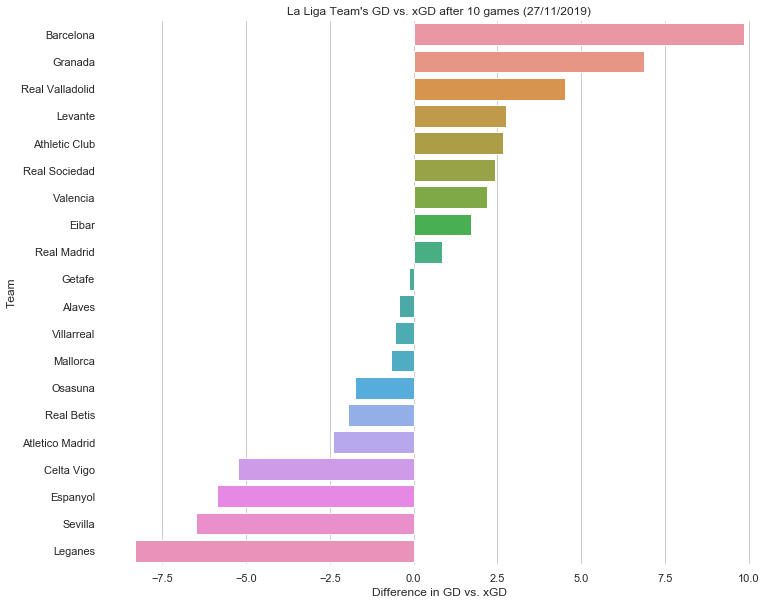

In [45]:
# Take a look at who has been overperforming or underperforming so far
df_xgleaguetable['GD_vs_xGD'] = df_xgleaguetable['GD'] - df_xgleaguetable['xGD']
df_xgleaguetable = df_xgleaguetable.sort_values(by=['Team'], ascending=False)

# Sort df_xgleaguetable DataFrame by GD_vs_xGD as opposed to team
df_xgleaguetable = df_xgleaguetable.sort_values(by=['GD_vs_xGD'], ascending=False)

# Set the width and height of the figure
plt.figure(figsize=(12,10))

# Set the plot style and colour palette
sns.set(style='whitegrid')
sns.set_color_codes('muted')

# Add title
plt.title("La Liga Team's GD vs. xGD after 10 games (27/11/2019)")

# Bar chart showing La Liga Team's GD vs. xGD after 10 games (27/11/2019)
sns_plot = sns.barplot(x=df_xgleaguetable['GD_vs_xGD'], y=df_xgleaguetable['Team'])

# Add labels for axes
plt.xlabel("Difference in GD vs. xGD")
plt.ylabel("Team")

# Remove the borders from the plot
sns.despine(left=True, bottom=True)

# Save plot
sns_plot = sns_plot.get_figure()
sns_plot.savefig("./figures/GD_vs_xGD_plot.png")

The plot shows that when looking at `xG` and `xGA` and subsequently `xGD`, after 10 games  Granada have been significantly overperforming what they were expected to achieve, with a difference of `xG` and `xGD` of nearly 7 goals (6.89). Only Barcelona have a greater difference in `xG` and `xGD` with nearly 10 goals.

This analysis would suggest that Granada are siginificately overperforming what is expected of them and in reality, they should be somewhere more around midtable position - 10th to be specific.

In [43]:
# Reset xG table order for future analysis
df_xgleaguetable = df_xgleaguetable.sort_values(by=['Position'], ascending=True)

In [44]:
df_xgleaguetable

,Team,M,W,D,L,G,GA,PTS,xG,xGA,xPTS,NPxG,NPxGA,GD,xGD,NPxGD,NPxGD Rank,GD_vs_xGD
Position,,,,,,,,,,,,,,,,,,
1,Granada,10,6,2,2,17,10,20,11.95,11.84,13.80,9.72,11.10,7,0.11,-1.38,10.0,6.89
2,Barcelona,9,6,1,2,23,10,19,13.50,10.35,14.21,13.50,8.87,13,3.15,4.63,5.0,9.85
3,Real Sociedad,10,6,1,3,17,10,19,14.84,10.27,15.96,12.61,9.53,7,4.57,3.08,6.0,2.43
4,Atletico Madrid,10,5,4,1,10,5,19,14.74,7.34,19.65,13.25,6.60,5,7.40,6.65,4.0,-2.40
5,Sevilla,10,6,1,3,13,11,19,17.50,9.00,19.68,17.50,8.26,2,8.50,9.24,2.0,-6.50
6,Real Madrid,9,5,3,1,16,9,18,16.00,9.86,16.71,16.00,9.12,7,6.14,6.88,3.0,0.86
7,Villarreal,10,5,2,3,24,14,17,20.99,10.43,21.11,18.76,8.20,10,10.56,10.56,1.0,-0.56
8,Osasuna,10,3,5,2,10,9,14,13.42,10.66,15.39,12.67,10.66,1,2.76,2.01,7.0,-1.76
9,Real Valladolid,10,3,5,2,10,9,14,11.21,14.73,11.81,9.72,13.99,1,-3.52,-4.27,16.0,4.52


### Matchup Adjustment

We want to use these xG stats to show has these can be used as a useful way to predict upcoming fixtures. In this case we will try to predict the average goals we can expect for each team in week 23 of the La Liga using using the xG_pg and xGA_pg after the first 22 games. I chose 22 games because this was just past the midway stage of the season, and the first time after some fixture congestion had been overcome and all the teams had played the same number of games (Real Madrid played had games to catch up on after [playing in the Club World Cup](https://www.bbc.co.uk/sport/football/30565151) as [winners of the previous season's UEFA Champions League](https://www.bbc.co.uk/sport/football/27383593)). This is a small game sample here so it’s hard to fully trust the results, but you will be able to use this method for any stats you want (shots, crosses etc). 

First, we need to import both fixtures for game week 23 and the xG league table after 22 games.

In [ ]:
# Load week 11 fixtures
df_league_fixtures_week23 = pd.read_csv('./data/laliga/1415/fixtures/la_liga_fixtures_week_23_1415.csv')
df_league_fixtures_week23

In [ ]:
# Load XG League Table after 22 games
df_la_liga_league_xG_22games = pd.read_csv('./data/laliga/1415/tables/la_liga_league_xG_22games_1415.csv')
df_la_liga_league_xG_22games = df_la_liga_league_xG_22games.set_index('Position')
df_la_liga_league_xG_22games

#### String formatting
To enable us to carry out further analysis, next we're going to create per game versions of each stat as well as the totals. The fastest way to do this is through a for loop and use of string formatting.

The string formatting operator, %, allows you to easily pass variables to a string. This can be used loop through values to create the new column names for our per game stats. First, we need to get a list of the column names we are interested in, then we can iterate over that list and generate a new column each time:

In [ ]:
# Print a list of the columns in the DataFrame
print(list(df_la_liga_league_xG_22games))

In [ ]:
# Desired columns
cols = ['G', 'GA', 'xG', 'xGA', 'NPxG', 'NPxGA', 'GD', 'xGD', 'NPxGD']
 
# Create new columns for per game versions of each stat in the cols list through for loop. The code iterates through the list and adds new columns for each item in the list, using string formatting to create the column names i.e. for each column in the cols list, create a new column where col name = original col name + '_pg' and col value = original column value / games
for col in cols:
    df_la_liga_league_xG_22games['%s_pg' % col] = df_la_liga_league_xG_22games[col] / df_la_liga_league_xG_22games['M']

df_la_liga_league_xG_22games

The table shows that after 22 games, Barcelona scored 3.18 goals per game, when they were only expected to score 2.49 goals per games, this is almost 0.7 goals a game more than expected. I would assume that this is unsustainable, even when accounting for some modelling error.

Likewise, they conceded 1.00 goals per game, when they were expected to concede 1.16 goals per game. This show that both offensively and defensively, Barcelona were doing better than expected.

Next, we want to combine these xG stats for each team per game (xG_pg and xGA_pg) and combine them with the upcoming fixtures to try to predict the average goals we can expect for each team in game week 23 of the La Liga season. We will do this by merging the two DataFrames.

#### Merging DataFames
The first step is to add xG_pg and xGA_pg to the fixtures dataframe. We can combine the fixtures and `df_la_liga_league_xG_22games_pg` dataframe using the Pandas merge operation, which works in a similar way to Excel's VLOOKUP function:

In [ ]:
# Filter xg_data to only include the columns we want
df_la_liga_league_xG_22games_pg = df_la_liga_league_xG_22games[['Team', 'xG_pg', 'xGA_pg']]

# Merge fixtures and xg_data_pg (see https://pandas.pydata.org/pandas-docs/stable/merging.html for more info on combining pandas dataframes)
# This will get home team stats by matching the 'Home_Team' column with the 'Team' column using left_on and right_on
df_league_fixtures_week23_xG = pd.merge(df_league_fixtures_week23, df_la_liga_league_xG_22games_pg, left_on='Home_Team', right_on='Team')
df_league_fixtures_week23_xG

In [ ]:
# We can repeat to get the away team stats
df_league_fixtures_week23_xG = pd.merge(df_league_fixtures_week23, df_la_liga_league_xG_22games_pg, left_on='Away_Team', right_on='Team')
df_league_fixtures_week23_xG

##### Removing and renaming dataframe columns
Whilst combining dataframes is a very useful tool in a lot of situations, in this case we have to remove the unwanted 'Team_x' and 'Team_y' columns and rename the others to avoid confusion:

In [ ]:
# Remove unwanted columns
# By default, the axis argument is set to 0, which refers to rows
# In this case we want to drop columns, so we need to specify axis=1
df_league_fixtures_week23_xG = df_league_fixtures_week23_xG.drop(['Team_x', 'Team_y'], axis=1)
df_league_fixtures_week23_xG

In [ ]:
# We have already seen that a list in Python is represented using square brackets []
# Curly brackets {} are used for dictionaries
# In a dictionary, the item on the left of the colon is the key, whilst the item on the right is the value
# We can use a dictionary to rename the columns in the fixtures dataframe
# This code will look for the dictionary keys in the column names, and replace them with the dictionary values
df_league_fixtures_week23_xG = df_league_fixtures_week23_xG.rename(columns={'xG_pg_x': 'xG_pg_home_team', 'xGA_pg_x': 'xGA_pg_home_team', 'xG_pg_y': 'xG_pg_away_team', 'xGA_pg_y': 'xGA_pg_away_team'})
df_league_fixtures_week23_xG

# Note that we could have assigned the dictionary to a variable instead:
# colnames = {'xG_pg_x': 'xG_pg_home', 'xGA_pg_x': 'xGA_pg_home', 'xG_pg_y': 'xG_pg_away', 'xGA_pg_y': 'xGA_pg_away'}
# fixtures = fixtures.rename(columns=colnames)

#### The map function
The other option is to use the map function to add the values from xg_data to fixture. Let's load the fixtures csv again so that we can try this method instead:

In [ ]:
# Load fixtures data again and assign to a new variable, fixtures2
df_league_fixtures_week23_2 = pd.read_csv('./data/laliga/1415/fixtures/la_liga_fixtures_week_23_1415.csv')

# First, set the 'Team' column of xg_data_pg to be the dataframe index
df_la_liga_league_xG_22games_pg.set_index('Team', inplace=True)
df_la_liga_league_xG_22games_pg

# inplace=True tells Python to complete the operation in place, avoiding the need to assign it back to a variable
# Alternatively we could have used the following code:
# xg_data_pg = xg_data_pg.set_index('Team')

In [ ]:
# Now we can use map to look for the values in a column from fixtures2 and get the corresponding value from xg_data_pg
# The code below looks for each 'Home_Team' in fixtures2 in the index of xg_data_pg, and maps the corresponding xG_pg back to fixtures2
df_league_fixtures_week23_2['xG_pg_home_team'] = df_league_fixtures_week23_2['Home_Team'].map(df_la_liga_league_xG_22games_pg['xG_pg'])

# We can repeat to get all the stats we want (of course there is a quicker way, but in this case there are only a few columns so it's not too bad to go one by one)
df_league_fixtures_week23_2['xGA_pg_home_team'] = df_league_fixtures_week23_2['Home_Team'].map(df_la_liga_league_xG_22games_pg['xGA_pg'])
df_league_fixtures_week23_2['xG_pg_away_team'] = df_league_fixtures_week23_2['Away_Team'].map(df_la_liga_league_xG_22games_pg['xG_pg'])
df_league_fixtures_week23_2['xGA_pg_away_team'] = df_league_fixtures_week23_2['Away_Team'].map(df_la_liga_league_xG_22games_pg['xGA_pg'])
df_league_fixtures_week23_2

In this case using map is probably easier, but it often won't be - for instance if we already had matching column names in the DataFrames we were combining.

#### Generating projected stats
Now we have the data we want, we can use simple method often used by Fantasy Football Analysts to adjust the xG numbers. The method we want is as follows:
adjusted stat = (offense * defense) / league average

In [ ]:
# Work out the average xGA_pg
la_liga_22games_xG_avg = df_la_liga_league_xG_22games_pg['xG_pg'].mean()

# Copy df_league_fixtures_week23_2 to a new DataFrame called matchups (you could just add the new columns directly to fixtures2 if you wanted)
df_matchups = df_league_fixtures_week23_2.copy()

# Add new columns for adjusted xG for home and away team
df_matchups['xG_adjusted_home_team'] = (df_matchups['xG_pg_home_team'] * df_matchups['xGA_pg_away_team']) / la_liga_22games_xG_avg
df_matchups['xG_adjusted_away_team'] = (df_matchups['xG_pg_away_team'] * df_matchups['xGA_pg_home_team']) / la_liga_22games_xG_avg
df_matchups

Ideally to make these numbers more useful, you will want to also factor in home advantage. Some teams will have a bigger home advantage than others due to various factors (e.g. level of support, different tactics of team or opponent etc), so if we had a larger sample our best option would be to use xG_pg at home or away rather than overall xG_pg. For now, a quick way to do this is to take the difference in average goals scored at home vs all matches. Since 14/15 teams have scored 1.1x more goals at home, with away teams scoring 0.87x as many goals.

In [ ]:
# Account for home advantage
df_matchups['xG_adjusted_home_team'] = df_matchups['xG_adjusted_home_team'] * 1.1
df_matchups['xG_adjusted_away_team'] = df_matchups['xG_adjusted_away_team'] * 0.87
df_matchups

#### Sense checking values
To check whether these numbers are realistic, let's compare them to the actual results of the matches.

In [ ]:
# Load results
df_results = pd.read_csv('data/laliga/1415/results/la_liga_results_week_23_1415.csv')

# Merge with matchups (here merging works well because we have the Home_Team and Away_Team columns in both dataframes)
df_matchups = pd.merge(df_matchups, df_results)

# Print a list of the columns in the DataFrame
print(list(df_matchups))

In [ ]:
df_matchups[['Home_Team', 'Away_Team', 'xG_adjusted_home_team', 'xG_adjusted_away_team', 'Home_Goals', 'Away_Goals']]

When subsetting the Home and Away Teams, their respective adjusted xG and then the actual results, we can see some useful prediction power in the results.

*    Almeria vs. Real Sociedad was predicted to be a 1-1 draw, it finished as a 2-2 draw.
*    Sevilla vs. Cordoba was predicted to be a 2-1 win to Sevilla, it finished as 3-0 win to Sevilla.
*    Real Madrid vs. Deportivo La Coruna was predicted to be a 4-0 win to Real Madrid, it finished as a 2-0 win to Madrid.
*    Granada vs. Athletic Club was predicted to be a 1-1 draw, it finished as a 0-0 draw.
*    Malaga vs. Espanyol was predicted to be a 1-1 draw, it finished as 0-2 win to Espanyol.
*    Valencia vs. Getafe was predicted to be a 1-1 draw (closer to 1.5-0.75), it finished as a 1-0 win to Valencia.
*    Barcelona vs. Levante was predicted to be a 4-1 win to Barcelona, it finished as a 5-0 win to Barcelona.
*    Rayo Vallecano vs. Villarreal was predicted to be a 1-1 draw, it finished as a 2-0 wiin to Rayo Vallecano
*    Celta Vigo vs. Atletico Madrid was prediced to be a 1-2 win to Atletico Madrid, it finished as a 2-0 win to Celta Vigo
*    Eibar vs. Elche was predicted to be a 1-1 draw, it finished as a 0-1 win to Elche.

No correct scores were predicted. Of the 10 games, 5 results were correctly predicted with a few other close results.

Generally our projected numbers and corresponding results don't look that bad despite using a pretty basic method. Organisations such as Opta and Statsbomb as well as betting companies will be using a larger sample of data than us as well as much more complicated, Machine Learning techniques, as well as adjusting a bit for how much action they expect from the public on each team.

We can next plot these results from the `df_matchups` DataFrame in Seaborn

In [ ]:
# Plot the results using the code from part 1
from matplotlib import pyplot as plt
import seaborn as sns

# Set the plot style and colour palette to use
sns.set(style='whitegrid')
sns.set_color_codes('muted')

# Initialize the matplotlib figure (f) and axes (ax), and set width and height of the plot
# In this case we want two plots, one each for home and away teams
# We can plot these on top of each other and use a shared x axis by calling nrows=2 and sharex=True
f, (ax1, ax2) = plt.subplots(nrows=2, figsize=(7, 10), sharex=True)

# Create the plots, choosing the axes, the variables for each axis, the data source and the colour
sns.barplot(x='home_goals_diff', y='Home_Team', data=matchups, color='b', ax=ax1)
sns.barplot(x='away_goals_diff', y='Away_Team', data=matchups, color='b', ax=ax2)

# Rename the axes, setting y axis label to be blank
ax1.set(xlabel='', ylabel='', title='Home Teams')
ax2.set(xlabel='Difference in bookies implied goals vs our projected goals', ylabel='', title='Away Teams')

# Remove the borders from the plot
sns.despine(left=True, bottom=True)

#### Creating functions
The final step in this part is to create a function to calculate the win and clean sheet odds for each team using our average projected goal numbers. We could do this without a function, but by wrapping our code inside a function we can use it again and again without having to re-type the same lines more than once. There is almost certainly a better way to achieve the same results than the code I have written here, so if you like feel free to play around and see if you can come up with an alternative! If you aren't sure what a part of the code is doing, try to run those lines separately, or add print statements inside the function to help explain.

In [ ]:
# Import the numpy module (package designed for scientific computing)
import numpy as np

# Define a function to calculate win and clean sheet percentages based on average goal totals for each team
# The general format is
# def function_name(function_inputs):
#     do things
#     return result
# It's always a good idea to include a 'docstring' in your function, which is a description of how to use the function surrounded by triple quotes
def win_cs(df, home_goals_col, away_goals_col, n=10000):
    """Generates win and clean sheet percentages for each row of a dataframe, df, by using average goal totals from home_goals_col and away_goals_col
    n = number of sims to run, set at 10000 by default"""
    
    # Create blank lists for wins and clean sheets
    home_win_list = []
    away_win_list = []
    home_cs_list = []
    away_cs_list = []
    
    # Iterate through each row (i) in the dataframe
    for i in range(len(df)):
        # Get home and away projected goals for that row
        avg_home_goals = df.iloc[i][home_goals_col]
        avg_away_goals = df.iloc[i][away_goals_col]

        # Simulate home and away goals by drawing from a random poisson distribution n times
        home_goals_sim = np.random.poisson(avg_home_goals, n)
        away_goals_sim = np.random.poisson(avg_away_goals, n)

        # Create a new dataframe, sim, with the columns as the results
        sim = pd.DataFrame({'home_score': home_goals_sim, 'away_score': away_goals_sim})

        # Add new columns by using np.where() to evaluate conditional expressions, setting 1 for true and 0 for false
        sim['home_win'] = np.where(sim['home_score'] > sim['away_score'], 1, 0)
        sim['away_win'] = np.where(sim['away_score'] > sim['home_score'], 1, 0)
        sim['home_clean_sheet'] = np.where(sim['away_score'] == 0, 1, 0)
        sim['away_clean_sheet'] = np.where(sim['home_score'] == 0, 1, 0)

        # Sum the number of each result and divide by total number of sims to get percentages
        # Append the result to the corresponding list each time
        # As we iterate through the dataframe the win and clean sheet percentages for each row will be added to the end of the lists, until eventually we have values for each row
        home_win_list.append(sim['home_win'].sum() / n)
        away_win_list.append(sim['away_win'].sum() / n)
        home_cs_list.append(sim['home_clean_sheet'].sum() / n)
        away_cs_list.append(sim['away_clean_sheet'].sum() / n)
        
    # Add new columns to the input dataframe from the lists containing win and clean sheet percentages
    df['home_win'] = np.asarray(home_win_list)
    df['away_win'] = np.asarray(away_win_list)
    df['home_clean_sheet'] = np.asarray(home_cs_list)
    df['away_clean_sheet'] = np.asarray(away_cs_list)
    
    return df

# Run our new function, specifying the paramaters we want as inputs
# Note that because we set n=10000 when we defined the function, we don't need to set a value of n here
matchups = win_cs(df=matchups, home_goals_col='xG_adjusted_home_team', away_goals_col='xG_adjusted_away_team')

# Check the results (note how you can re-order the columns)
displaycols = ['Home_Team', 'xG_adjusted_home_team', 'home_win', 'home_clean_sheet',
               'Away_Team', 'xG_adjusted_away_team', 'away_win', 'away_clean_sheet']
matchups[displaycols]

In [ ]:
# Because we put our previous code inside a function, we can easily re-run the function using the bookies' implied totals instead
matchups2 = win_cs(df=matchups, home_goals_col='Home_Goals', away_goals_col='Away_Goals')

# Check the results (note how you can re-order the columns)
displaycols = ['Home_Team', 'Home_Goals', 'home_win', 'home_clean_sheet',
               'Away_Team', 'Away_Goals', 'away_win', 'away_clean_sheet']
matchups2[displaycols]

### Individual Player xG Stats

In [ ]:
df_player_xg = pd.read_csv('data/laliga/1415/players/la_liga_players_xG_1415.csv')
df_player_xg

#### Initial Analysis

The xG League Table has twenty features:
*    `Position`: 
*    `Player`: 
*    `Team`: 
*    `Apps`: 
*    `Min`: 
*    `G`: No. goals scored
*    `NPG`: 
*    `A`: 
*    `xG`: Expected Goals
*    `NPxG`: Non-Penalty Expected Goals
*    `xA`: 
*    `xGChain`: 
*    `xGBuildup`: 
*    `xG90`: 
*    `NPxG90`: 
*    `xA90`: 
*    `xG90 + xA90`: 
*    `NPxG90 + xA90`: 
*    `xGChain90`: 
*    `xGBuildup90`: 

<a id='sectionsummary'></a>

## Summary

Hopefully this notebook provides a good idea of what a Machine Learning project looks like, and showed you some of the tools you can use to train a great system. As you can see, much of the work is in the data preparation step, building monitoring tools, setting up human evaluation pipelines, and automating regular model training. The Machine Learning algorithms are also important, of course, but it is probably preferable to be comfortable with the overall process and know three or four algorithms well rather than to spend all your time exploring advanced algorithms and not enough time on the overall process.

## Next Steps

Look at other metrics including expected assists (xA), xGChain and xGBuildup. These metric can be standardised and combined to create metrics such as xG90, NPxG90, xA90, xG90 + xA90, NPxG90 + xA90, xGChain90, and xGBuildup90.

<a id='sectionbib'></a>

## Bibliography

* [Understat.com](https://understat.com/). The La Liga 2014/15 season table used specifically for this project can be found [here](https://understat.com/league/La_liga/2014).
* [Datahub.io Spanish La Liga data repository](https://datahub.io/sports-data/spanish-la-liga)

## Further Reading

* [The Future of Stats: xG, xA by Tifo Football Podcast](https://www.youtube.com/watch?v=sNCeA27sDvI)
* [What is xG? YouTube video by Tifo Football](https://www.youtube.com/watch?v=zSaeaFcm1SY)
* [What are Expected Assists? YouTube video by Tifo Football](https://www.youtube.com/watch?v=1MdlkuzLdj4)
<br>

<a id='sectionappendix'></a>

## Appendix

List of functions/methods used:

***Visit my website [EddWebster.com](https://www.eddwebster.com) or my [GitHub Repository](https://github.com/eddwebster) for more projects. If you'd like to get in contact, my email is: edd.j.webster@gmail.com.***